In [10]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from files.genpulse import genpulse
from files.rosenmodel import rosenmodel
from IPython.display import Audio, display   # για να "παίζουμε" ήχους

## Άσκηση - Σύνθεση ομιλίας με κανόνες formant (formant synthesis)

Στην άσκηση $\texttt{Ex-VowelSynthesis}$ - που ΠΡΕΠΕΙ να δείτε πριν προχωρήσετε παρακάτω - συνθέσαμε **μεμονωμένα φωνήεντα** (/α/, /ε/, /ο/). Καθένα προέκυψε περνώντας μια σειρά γλωττιδικών παλμών μέσα από ένα **σταθερό** φίλτρο φωνητικής οδού $V(z)$ — δηλαδή με σταθερά formants. Όμως η ομιλία **δεν είναι στατική**: όταν μιλάμε, η γλώσσα, τα χείλη και η γνάθος κινούνται συνεχώς, άρα η φωνητική οδός — και μαζί τα formants — **αλλάζουν με τον χρόνο**.

Η βασική ιδέα της σύνθεσης ομιλίας με formants (μια από τις παλαιότερες, τύπου Klatt (https://www.fon.hum.uva.nl/david/ma_ssp/doc/Klatt-1980-JAS000971.pdf)) είναι απλή:

>> **Ομιλία $=$ μια πηγή διέγερσης που περνά μέσα από ένα φίλτρο της φωνητικής οδού, του οποίου οι συχνότητες μεταβάλλονται με τον χρόνο.**

Ο ρόλος των **«κανόνων» (rules)** είναι διπλός:
1. Ένας **πίνακας formnats-στόχων**: για κάθε φώνημα ορίζουμε τις συχνότητες formant $F_1, F_2, F_3$ στις οποίες «στοχεύει» η φωνητική οδός.

2. Ένας **κανόνας μετάβασης** (coarticulation): πώς μεταβάλλονται τα formants από τον στόχο ενός φωνήματος στον στόχο του επόμενου.

Θα συνθέσουμε τη λέξη **«μιλάω»** — μια πλήρως *έμφωνη* λέξη (όλα τα φωνήματα $/m/,/i/,/l/,/a/,/o/$ παράγονται με πάλλουσες φωνητικές χορδές), ώστε να μείνουμε στο απλό μοντέλο πηγής–φίλτρου, χωρίς άφωνους (θορυβώδεις) ήχους. Η ποιότητα δεν μας απασχολεί: ο στόχος είναι να **δούμε και να ακούσουμε** πώς η κίνηση των formants φτιάχνει ομιλία.

Ακολουθήστε τα παρακάτω βήματα.

(α') Ορίστε τη συχνότητα δειγματοληψίας $f_s = 8000$ Hz (ίδια με πριν, άρα τα formants πρέπει να είναι όλα μικρότερα από $4000$ Hz).

In [11]:
# Συχνότητα δειγματοληψίας
fs = 8000

(β') **Ο πίνακας formant (οι «κανόνες»):** Ένα ζεύγος συζυγών πόλων $z_k = r_k e^{\pm j\Omega_k}$ "φτιάχνει" ένα formant για το φίλτρο της φωνητικής οδού. Όπως δείξαμε σε προηγούμενη σχετική άσκηση, η **γωνία** δίνει τη συχνότητα και το **μέτρο** δίνει το εύρος ζώνης:

$$\Omega_k = \frac{2\pi F_k}{f_s}, \qquad r_k = e^{-\pi B_k / f_s}.$$

Ορίζουμε τη βοηθητική `formant_filter` που χτίζει τον παρονομαστή του all-pole φίλτρου $V(z)$, και έναν πίνακα με τα formant-στόχους κάθε φωνήματος. 

Παρατηρήστε ότι το ρινικό $/m/$ έχει μειωμένο κέρδος (φράσσεται το στόμα, ακούγεται πιο «μουντό»), ενώ τα φωνήεντα ξεχωρίζουν κυρίως από το $F_2$.

In [12]:
def formant_filter(formants, bandwidths, fs=fs):
    """Παρονομαστής του all-pole V(z) από συχνότητες formant και εύρη ζώνης (Hz)."""
    den = np.array([1.0])
    for F, B in zip(formants, bandwidths):
        r = np.exp(-np.pi * B / fs)
        theta = 2 * np.pi * F / fs
        den = np.convolve(den, [1.0, -2 * r * np.cos(theta), r * r])
    return den

# Πίνακας στόχων: F = [F1,F2,F3] (Hz), B = εύρη ζώνης (Hz), gain = σχετικό κέρδος
PHON = {
    'm': dict(F=[250, 1100, 2400], B=[120, 120, 150], gain=0.6),  # ρινικό
    'i': dict(F=[300, 2200, 2900], B=[ 60, 100, 150], gain=1.0),
    'l': dict(F=[350, 1200, 2600], B=[ 80, 100, 150], gain=0.85), # πλευρικό
    'a': dict(F=[700, 1150, 2600], B=[ 80,  90, 120], gain=1.0),
    'o': dict(F=[450,  850, 2600], B=[ 70,  90, 120], gain=1.0),
}

(γ') **Η «παρτιτούρα» της λέξης:** Γράφουμε τη λέξη ως ακολουθία (φώνημα, διάρκεια σε δευτερόλεπτα). Οι διάρκειες είναι επίσης «κανόνας» — εδώ δίνουμε στα φωνήεντα λίγο μεγαλύτερη διάρκεια από τα σύμφωνα.

In [ ]:
# «μιλάω» -> /m i l a o/
score = [('m', 0.09), ('i', 0.13), ('l', 0.08), ('a', 0.15), ('o', 0.16)]
total = sum(d for _, d in score)
N = int(round(total * fs))

print(f'Συνολική διάρκεια: {total:.2f} s  ->  {N} δείγματα')

Συνολική διάρκεια: 0.61 s  ->  4880 δείγματα


(δ') **Κανόνας μετάβασης (coarticulation):** Θα υιοθετήσουμε την κατασκευή των formant tracks με γραμμική παρεμβολή! 

Τοποθετούμε έναν «στόχο» στο **κέντρο** κάθε φωνήματος και αφήνουμε τα formants να **μεταβάλλονται γραμμικά** από τον έναν στόχο στον επόμενο. Αν στη χρονική στιγμή $t$ βρισκόμαστε ανάμεσα στους στόχους $F^{(p)}$ και $F^{(q)}$ (στους χρόνους $t_p, t_q$), τότε

$$F_k(t) = F_k^{(p)} + \frac{t - t_p}{t_q - t_p}\,\big(F_k^{(q)} - F_k^{(p)}\big).$$

Αυτή η ομαλή κίνηση των formants είναι ακριβώς αυτό που αντιλαμβάνεται το αυτί ως «συνεχή ομιλία» αντί για "κομμένα" φωνήεντα. Σχεδιάζουμε τα $F_1, F_2, F_3(t)$ για να τα δούμε.

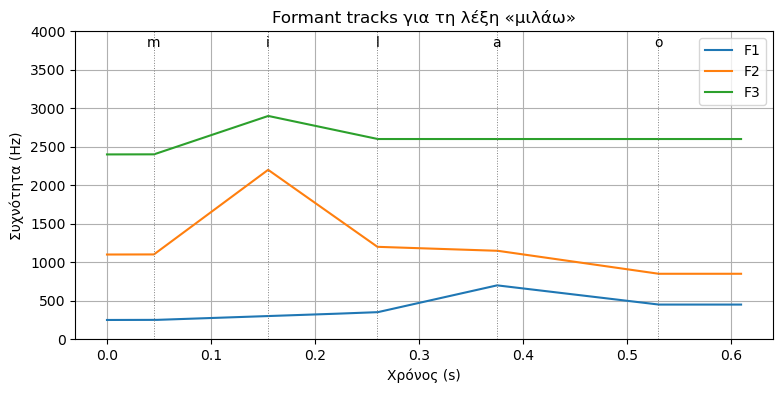

In [ ]:
# Κόμβοι-στόχοι στο κέντρο κάθε φωνήματος (+ αγκύρωση στα άκρα)
t_acc, centers = 0.0, []
for ph, d in score:
    centers.append((t_acc + d / 2, ph)); t_acc += d
node_t  = [0.0] + [c[0] for c in centers] + [total]
node_ph = [score[0][0]] + [c[1] for c in centers] + [score[-1][0]]

t = np.arange(N) / fs
F  = [np.zeros(N) for _ in range(3)]   # F1,F2,F3 tracks
B  = [np.zeros(N) for _ in range(3)]   # bandwidth tracks
gain = np.zeros(N)

for k in range(len(node_t) - 1):
    t0, t1 = node_t[k], node_t[k + 1]
    p0, p1 = PHON[node_ph[k]], PHON[node_ph[k + 1]]
    seg = (t >= t0) & (t < t1)
    frac = (t[seg] - t0) / (t1 - t0 + 1e-9)
    for r in range(3):
        F[r][seg] = p0['F'][r] + frac * (p1['F'][r] - p0['F'][r])  # INSERT CODE HERE
        B[r][seg] = p0['B'][r] + frac * (p1['B'][r] - p0['B'][r])  # INSERT CODE HERE
    gain[seg] = p0['gain'] + frac * (p1['gain'] - p0['gain'])
for r in range(3): F[r][-1] = F[r][-2]; B[r][-1] = B[r][-2]
gain[-1] = gain[-2]

plt.figure(figsize=(9, 4))
for r, name in zip(range(3), ['F1', 'F2', 'F3']):
    plt.plot(t, F[r], label=name)
for tc, ph in centers:
    plt.axvline(tc, color='gray', ls=':', lw=0.7)
    plt.text(tc, 3800, ph, ha='center')
plt.ylim(0, 4000); plt.xlabel('Χρόνος (s)'); plt.ylabel('Συχνότητα (Hz)')
plt.title('Formant tracks για τη λέξη «μιλάω»'); plt.legend(); plt.grid(True); plt.show()

(ε') **Πηγή διέγερσης με περίγραμμα τόνου (pitch):** Όπως πριν, η πηγή είναι μια σειρά γλωττιδικών παλμών. Για λίγη φυσικότητα, αφήνουμε τη θεμελιώδη $f_0$ να πέφτει ελαφρά μέσα στη λέξη (φυσική «πτώση τόνου» / declination), από $130$ σε $100$ Hz. Τοποθετούμε δηλαδή κρουστικές με **στιγμιαία περίοδο** $P(n) = f_s / f_0(n)$ και τις συνελίσσουμε με έναν παλμό Rosenberg.

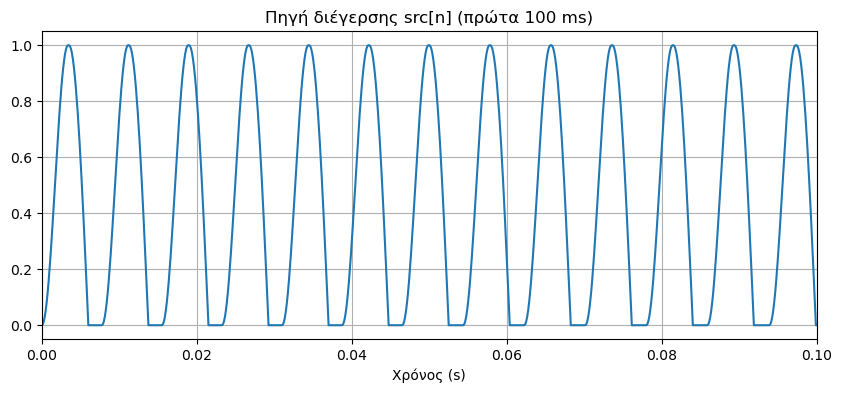

In [42]:
f0_contour = np.linspace(130, 100, N)     # ελαφριά πτώση τόνου

exc = np.zeros(N)                          # θέσεις κρουστικών (στιγμιαία περίοδος)
n = 0
while n < N:
    exc[n] = 1.0
    n += max(int(round(fs / f0_contour[n])), 1)

g = rosenmodel(round(0.4 * fs / 120), round(0.3 * fs / 120), 120).reshape(-1)  # σχήμα γλωττιδικού παλμού
src = sig.convolve(exc, g)[:N]

plt.figure(figsize=(10, 4))
plt.plot(t, src); plt.xlim(0, 0.1)
plt.title('Πηγή διέγερσης src[n] (πρώτα 100 ms)'); plt.xlabel('Χρόνος (s)'); plt.grid(True); plt.show()

(στ') **Χρονικά μεταβαλλόμενο φίλτρο $V(z,n)$:** Τώρα η καρδιά της μεθόδου. Χωρίζουμε το σήμα σε μικρά **πλαίσια** (frames) των $64$ δειγμάτων ($8$ ms). Σε κάθε πλαίσιο χτίζουμε ένα **στιγμιαίο** $V(z)$ από τα formants που ισχύουν στο κέντρο του πλαισίου, και φιλτράρουμε μόνο αυτό το κομμάτι.

Κρίσιμη λεπτομέρεια: για να **μην ακούγονται «κλικ»** στα όρια των πλαισίων, μεταφέρουμε την **εσωτερική κατάσταση** του φίλτρου (τα `zi`) από το ένα πλαίσιο στο επόμενο — έτσι το φίλτρο θυμάται το παρελθόν του και η έξοδος παραμένει συνεχής παρότι οι συντελεστές αλλάζουν.

In [ ]:
frame = 64                                  # ~8 ms
n_poles = 2 * 3                             # 3 ζεύγη συζυγών πόλων -> τάξη 6
zi = np.zeros(n_poles)                      # αρχική κατάσταση φίλτρου
out = np.zeros(N)

for s in range(0, N, frame):
    e = min(s + frame, N)
    i = (s + e) // 2                        # δείκτης στο κέντρο του πλαισίου
    den = formant_filter([F[0][i], F[1][i], F[2][i]],
                         [B[0][i], B[1][i], B[2][i]])
    b = [gain[i]]                           # κέρδος του τρέχοντος φωνήματος
    out[s:e], zi = sig.lfilter(b, den, src[s:e], zi=zi)  # μεταφορά κατάστασης! Δείτε το documentation της lfilter.

(ζ') **Επίδραση χειλιών και κανονικοποίηση.** Ακριβώς όπως στα φωνήεντα, περνάμε την έξοδο από το $R(z) = 1 - 0.95 z^{-1}$ (μετατροπή ταχύτητας ροής σε πίεση) και κανονικοποιούμε.

In [27]:
speech = sig.lfilter([1, -0.95], [1], out)
speech = speech / np.max(np.abs(speech))

(η') **Ακούστε το!** Θα πρέπει να ακουστεί ένα ρομποτικό αλλά αναγνωρίσιμο «μιλάω».

In [28]:
Audio(speech, rate=fs)

(θ') **Επαλήθευση με φασματογράφημα:** Σχεδιάζουμε το φασματογράφημα του τελικού σήματος και επάνω του τα formant tracks που σχεδιάσαμε στο (δ'). Οι σκούρες λωρίδες ενέργειας πρέπει να **ακολουθούν** τις καμπύλες — απόδειξη ότι τα κινούμενα formants είναι όντως αυτά που «γράφουν» τη λέξη.

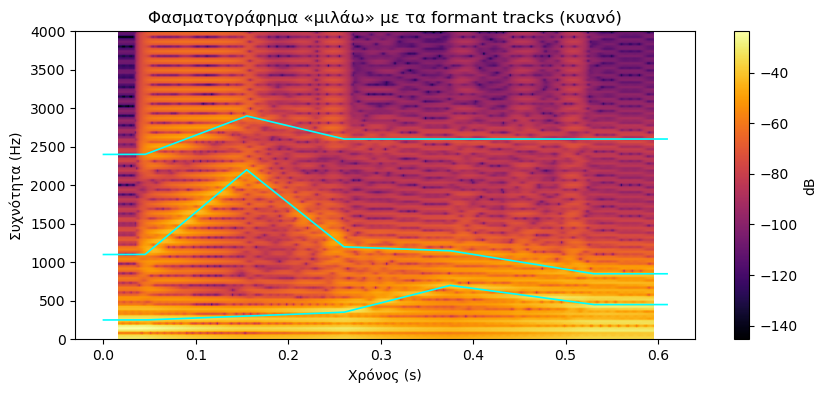

In [45]:
plt.figure(figsize=(10, 4))
plt.specgram(speech, NFFT=256, Fs=fs, noverlap=244, cmap='inferno')
for r in range(3):
    plt.plot(t, F[r], color='cyan', lw=1.2)
plt.ylim(0, 4000); plt.xlabel('Χρόνος (s)'); plt.ylabel('Συχνότητα (Hz)')
plt.title('Φασματογράφημα «μιλάω» με τα formant tracks (κυανό)')
plt.colorbar(label='dB'); plt.show()

(ι') **Πειραματιστείτε:**
* Αλλάξτε τη λέξη: φτιάξτε άλλη πλήρως έμφωνη ακολουθία (π.χ. «νερό» $/n\,e\,r\,o/$, «ελιά» $/e\,l\,i\,a/$) προσθέτοντας τα φωνήματα στο `PHON` και αλλάζοντας το `score`.

* Αλλάξτε τις διάρκειες στο `score` — πολύ μικρές διάρκειες κάνουν την ομιλία «βιαστική» και δυσνόητη.

* Πειραματιστείτε με το περίγραμμα `f0_contour`: μια πιο έντονη πτώση ακούγεται σαν κατάφαση, μια άνοδος στο τέλος σαν ερώτηση.

* Δοκιμάστε να προσθέσετε λίγο τυχαίο θόρυβο χαμηλής ισχύος στο `exc` για φυσικότητα, όπως στο εργαστήριο των φωνηέντων.

**Τι λείπει για «πραγματική» ομιλία;** Άφωνοι ήχοι (π.χ. /s/, /t/) που χρειάζονται **θορυβώδη** πηγή αντί για γλωττιδικούς παλμούς, και τα ρινικά χρειάζονται και **μηδενικά** (anti-formants) — όχι μόνο πόλους. Αυτά θα ήταν η αμέσως επόμενη προσθήκη σε ένα μοντέλο τύπου Klatt.

---
---